In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
from pathlib import Path

# ── 1. Time Windows (Strict Baseline Separation) ───────────────────────────
EVENT_TIMESTAMP = pd.to_datetime("2023-10-07 03:30:00")
START_WINDOW    = pd.to_datetime("2023-10-01 00:00:00")
END_WINDOW      = pd.to_datetime("2023-10-21 23:45:00")

# Quiet Baseline: September 2023
BASELINE_START  = pd.to_datetime("2023-09-01 00:00:00")
BASELINE_END    = pd.to_datetime("2023-09-30 23:45:00")

# ── 2. Data Loading & Event Slicing ────────────────────────────────────────
dir_geo = Path("data/indicators_geo_IS_15min")
files = list(dir_geo.glob("*.parquet"))

if files:
    df = pd.concat([pd.read_parquet(f) for f in files], ignore_index=True)
    df["period"] = pd.to_datetime(df["period"])
    df = df.groupby(["period", "region_key"], as_index=False).first()
    
    # Event window
    df_event = df[(df["period"] >= START_WINDOW) & (df["period"] <= END_WINDOW)].copy()
    df_event.sort_values(by=["period", "region_key"], inplace=True)
else:
    raise FileNotFoundError(f"No parquet files found in {dir_geo}")

# ── 3. Abnormal Metric Calculation ─────────────────────────────────────────
def compute_event_abnormal_metrics(df_full, df_window, base_start, base_end, metric_cols):
    df_out = df_window.copy()
    # Baseline calculated strictly from the pre-event month
    baseline_df = df_full[(df_full["period"] >= base_start) & (df_full["period"] <= base_end)]
    
    for col in metric_cols:
        if col not in df_out.columns:
            continue
            
        stats = baseline_df.groupby("region_key")[col].agg(["mean", "std"]).reset_index()
        stats.rename(columns={"mean": f"{col}_base_mean", "std": f"{col}_base_std"}, inplace=True)
        
        df_out = df_out.merge(stats, on="region_key", how="left")
        df_out[f"{col}_zscore"] = (df_out[col] - df_out[f"{col}_base_mean"]) / df_out[f"{col}_base_std"].replace(0, np.nan)
        df_out.drop(columns=[f"{col}_base_mean", f"{col}_base_std"], inplace=True)
        
    return df_out

target_metrics = [c for c in df_event.columns if c.startswith(("att_weight_", "sent_cont_"))]
df_event_proc = compute_event_abnormal_metrics(df, df_event, BASELINE_START, BASELINE_END, target_metrics)

✔ Granular event study chart saved to: Fig_Oct7_Granular_Shock.pdf


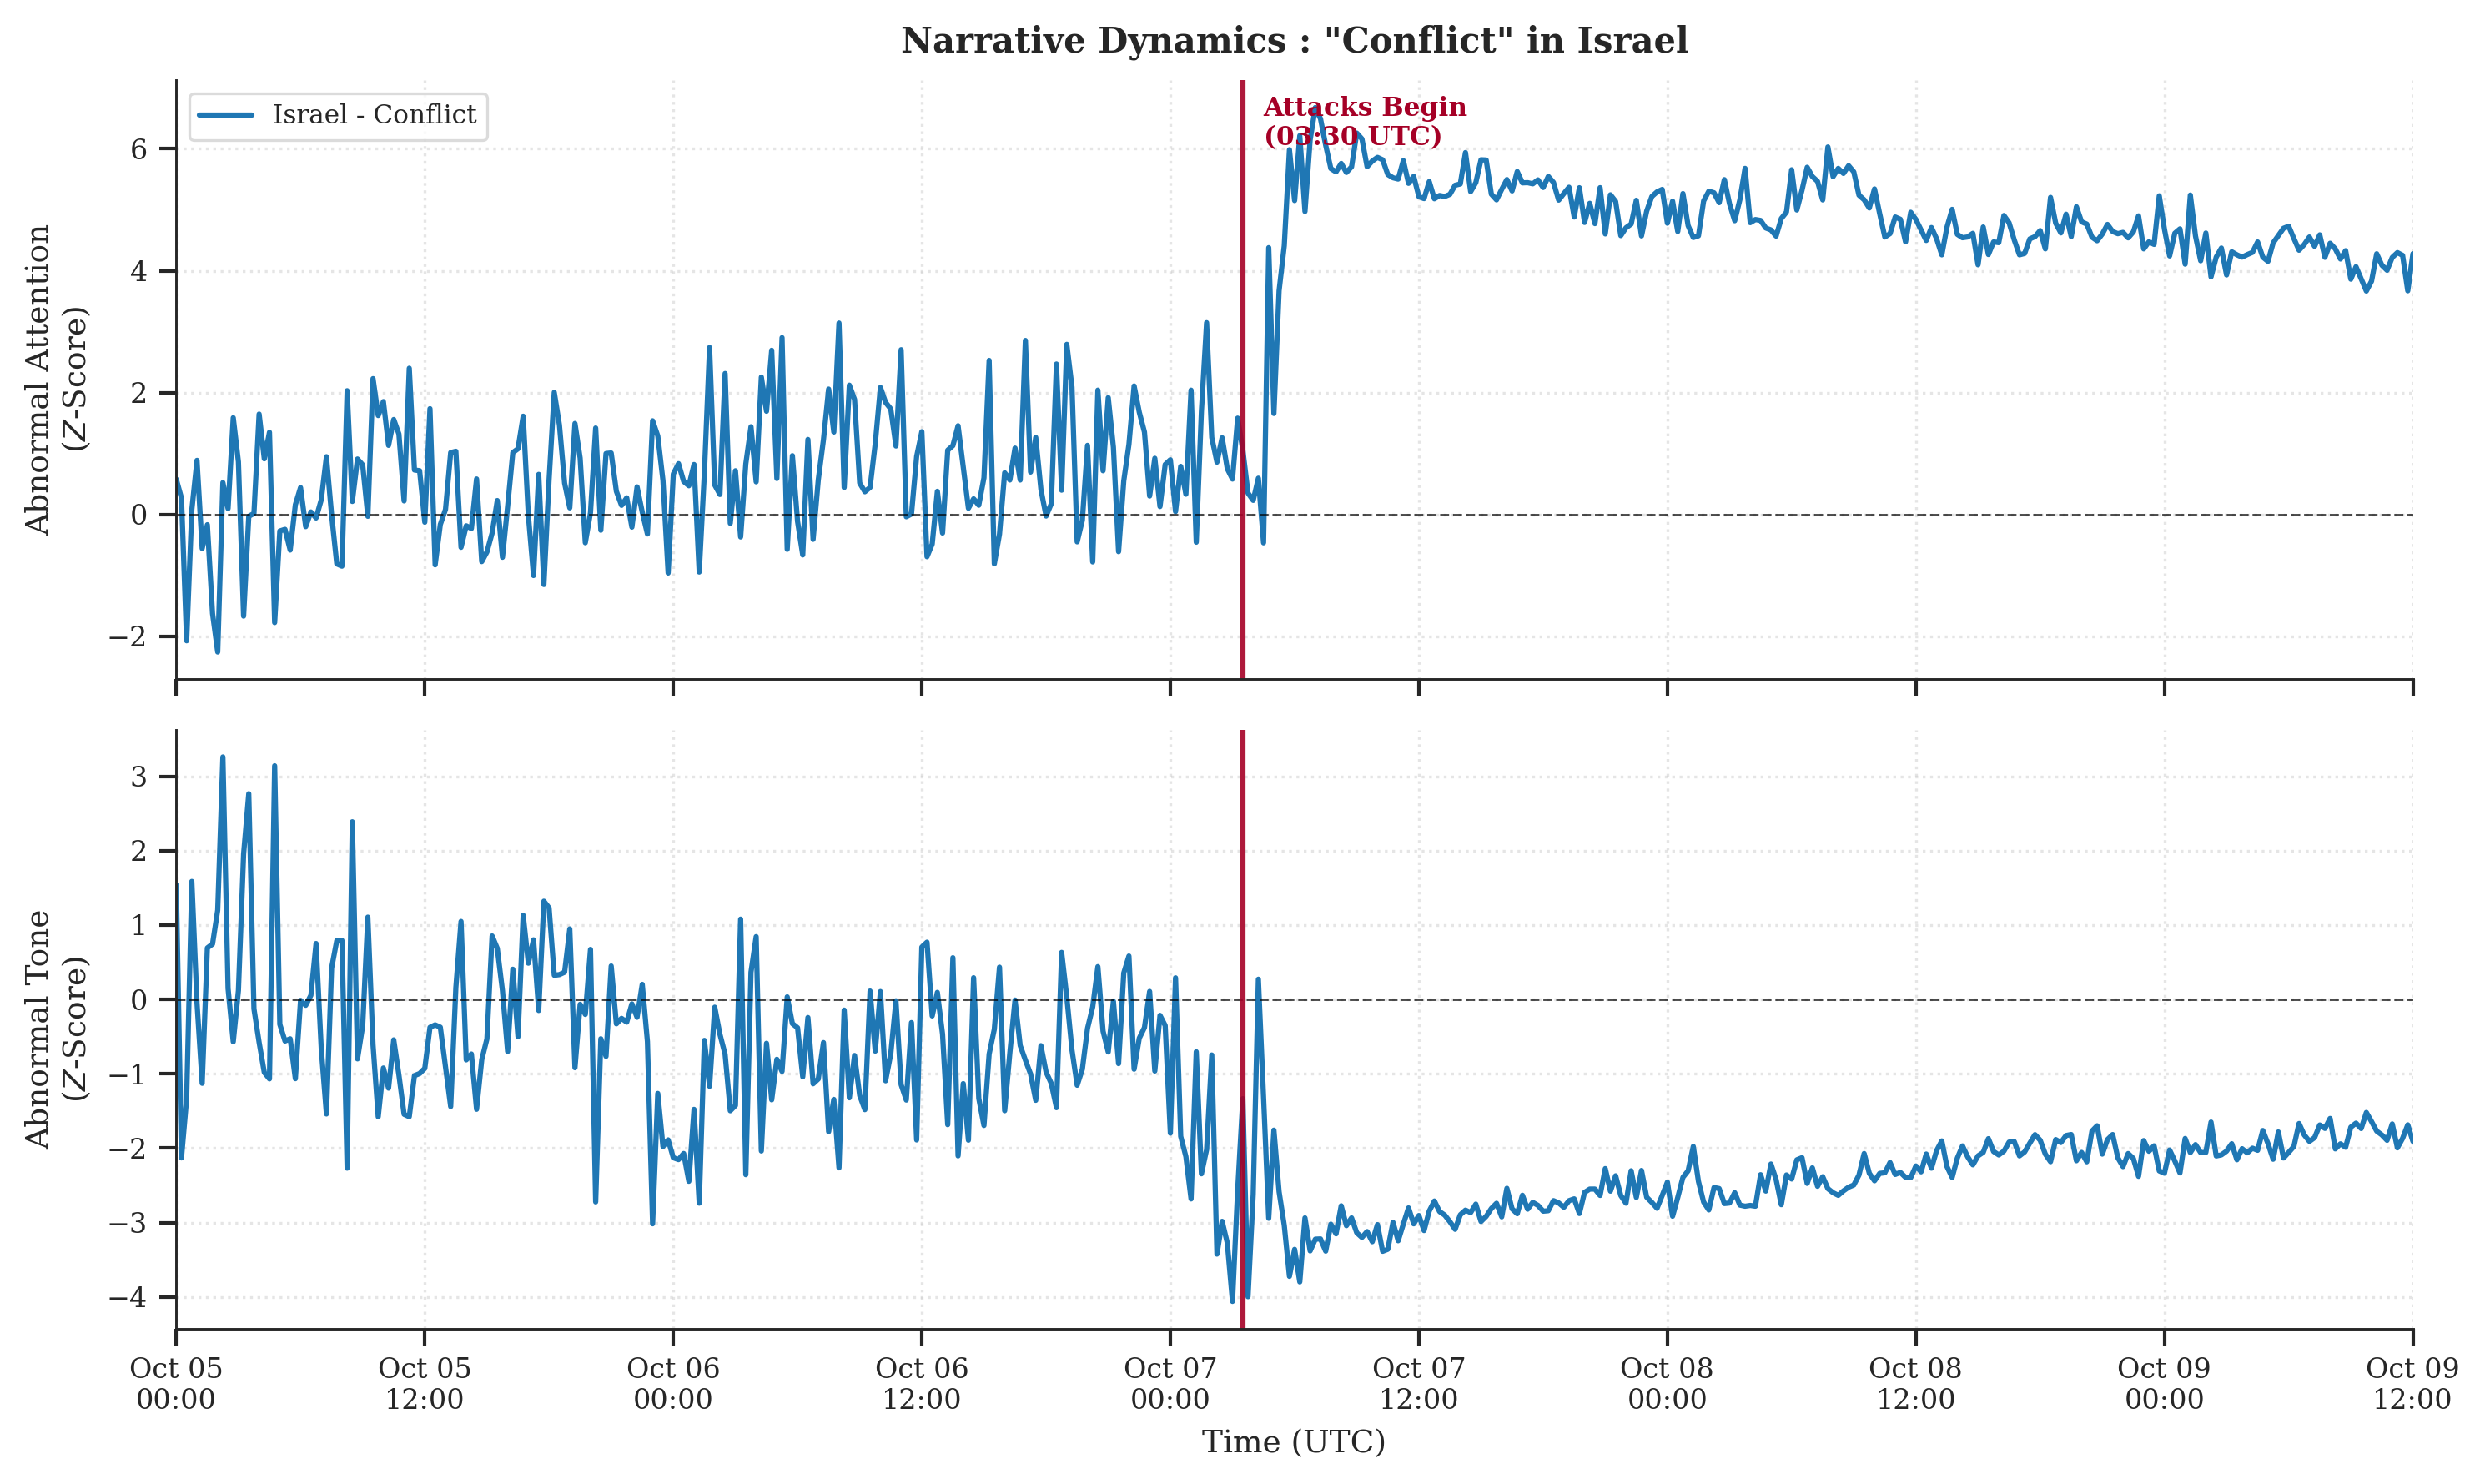

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
import pandas as pd

def plot_oct7_granular_shock(df_data, metric_suffix="conflict", smoothing_window=2, filename="Fig_Oct7_Granular_Shock.pdf"):
    """
    Plots a highly granular 15-minute event study focusing strictly on Oct 6 - Oct 8.
    """
    # ── 1. Define the Micro-Window ───────────────────────────────────────────
    zoom_start = pd.to_datetime("2023-10-05 00:00:00")
    zoom_end   = pd.to_datetime("2023-10-09 12:00:00") # Include early Oct 8 to see the peak
    
    plot_df = df_data[(df_data["period"] >= zoom_start) & (df_data["period"] <= zoom_end)].copy()

    # ── 2. Aesthetics & Smoothing ────────────────────────────────────────────
    sns.set_theme(style="ticks", context="paper")
    plt.rcParams.update({
        "font.family": "serif",
        "font.size": 9,
        "axes.titlesize": 10,
        "axes.labelsize": 9,
        "xtick.labelsize": 8,
        "ytick.labelsize": 8,
        "axes.linewidth": 0.7,
        "figure.dpi": 300,
        "savefig.bbox": "tight"
    })

    col_att  = f"att_weight_{metric_suffix}_zscore"
    col_sent = f"sent_cont_{metric_suffix}_zscore"

    if smoothing_window > 1:
        plot_df[col_att]  = plot_df.groupby("region_key")[col_att].transform(lambda x: x.rolling(smoothing_window, min_periods=1).mean())
        plot_df[col_sent] = plot_df.groupby("region_key")[col_sent].transform(lambda x: x.rolling(smoothing_window, min_periods=1).mean())

    # ── 3. Plotting the Panels ───────────────────────────────────────────────
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
    regions = plot_df["region_key"].unique()
    palette = sns.color_palette("tab10", len(regions))

    # Panel 1: Attention
    for idx, reg in enumerate(regions):
        sub = plot_df[plot_df["region_key"] == reg]
        ax1.plot(sub["period"], sub[col_att], label="Israel - Conflict", color=palette[idx], linewidth=1.5)

    ax1.axhline(0, color="black", linestyle="--", linewidth=0.7, alpha=0.7)
    ax1.axvline(EVENT_TIMESTAMP, color="#a50026", linestyle="-", linewidth=1.5, alpha=0.9)
    ax1.set_ylabel("Abnormal Attention\n($Z$-Score)")
    ax1.set_title("Narrative Dynamics : \"Conflict\" in Israel", fontweight="bold", pad=8)
    ax1.grid(True, linestyle=":", alpha=0.5)

    # Panel 2: Sentiment
    for idx, reg in enumerate(regions):
        sub = plot_df[plot_df["region_key"] == reg]
        ax2.plot(sub["period"], sub[col_sent], label="Israel - Conflict", color=palette[idx], linewidth=1.5)

    ax2.axhline(0, color="black", linestyle="--", linewidth=0.7, alpha=0.7)
    ax2.axvline(EVENT_TIMESTAMP, color="#a50026", linestyle="-", linewidth=1.5, alpha=0.9)
    ax2.set_ylabel("Abnormal Tone\n($Z$-Score)")
    ax2.set_xlabel("Time (UTC)")
    ax2.grid(True, linestyle=":", alpha=0.5)

    # ── 4. Snap to Outer Edges & Granular X-Axis Formatting ──────────────────
    # 🔥 Snap curve to the outer left and right edges (removes padding)
    ax1.set_xlim(zoom_start, zoom_end)

    ax1.text(
        EVENT_TIMESTAMP + pd.Timedelta(hours=1), 
        ax1.get_ylim()[1] * 0.85, 
        "Attacks Begin\n(03:30 UTC)", 
        color="#a50026", fontsize=7.5, fontweight="semibold"
    )
    
    # Set ticks to every 6 hours
    ax2.xaxis.set_major_locator(mdates.HourLocator(interval=12))
    ax2.xaxis.set_major_formatter(mdates.DateFormatter("%b %d\n%H:%M"))
    
    ax1.legend(loc="upper left", frameon=True, facecolor="white", edgecolor="lightgray", fontsize=7.5)

    sns.despine()
    plt.tight_layout()
    plt.savefig(filename)
    print(f"✔ Granular event study chart saved to: {filename}")
    plt.show()

# Run the plot using the previously processed dataframe
plot_oct7_granular_shock(df_event_proc, metric_suffix="conflict", smoothing_window=1)

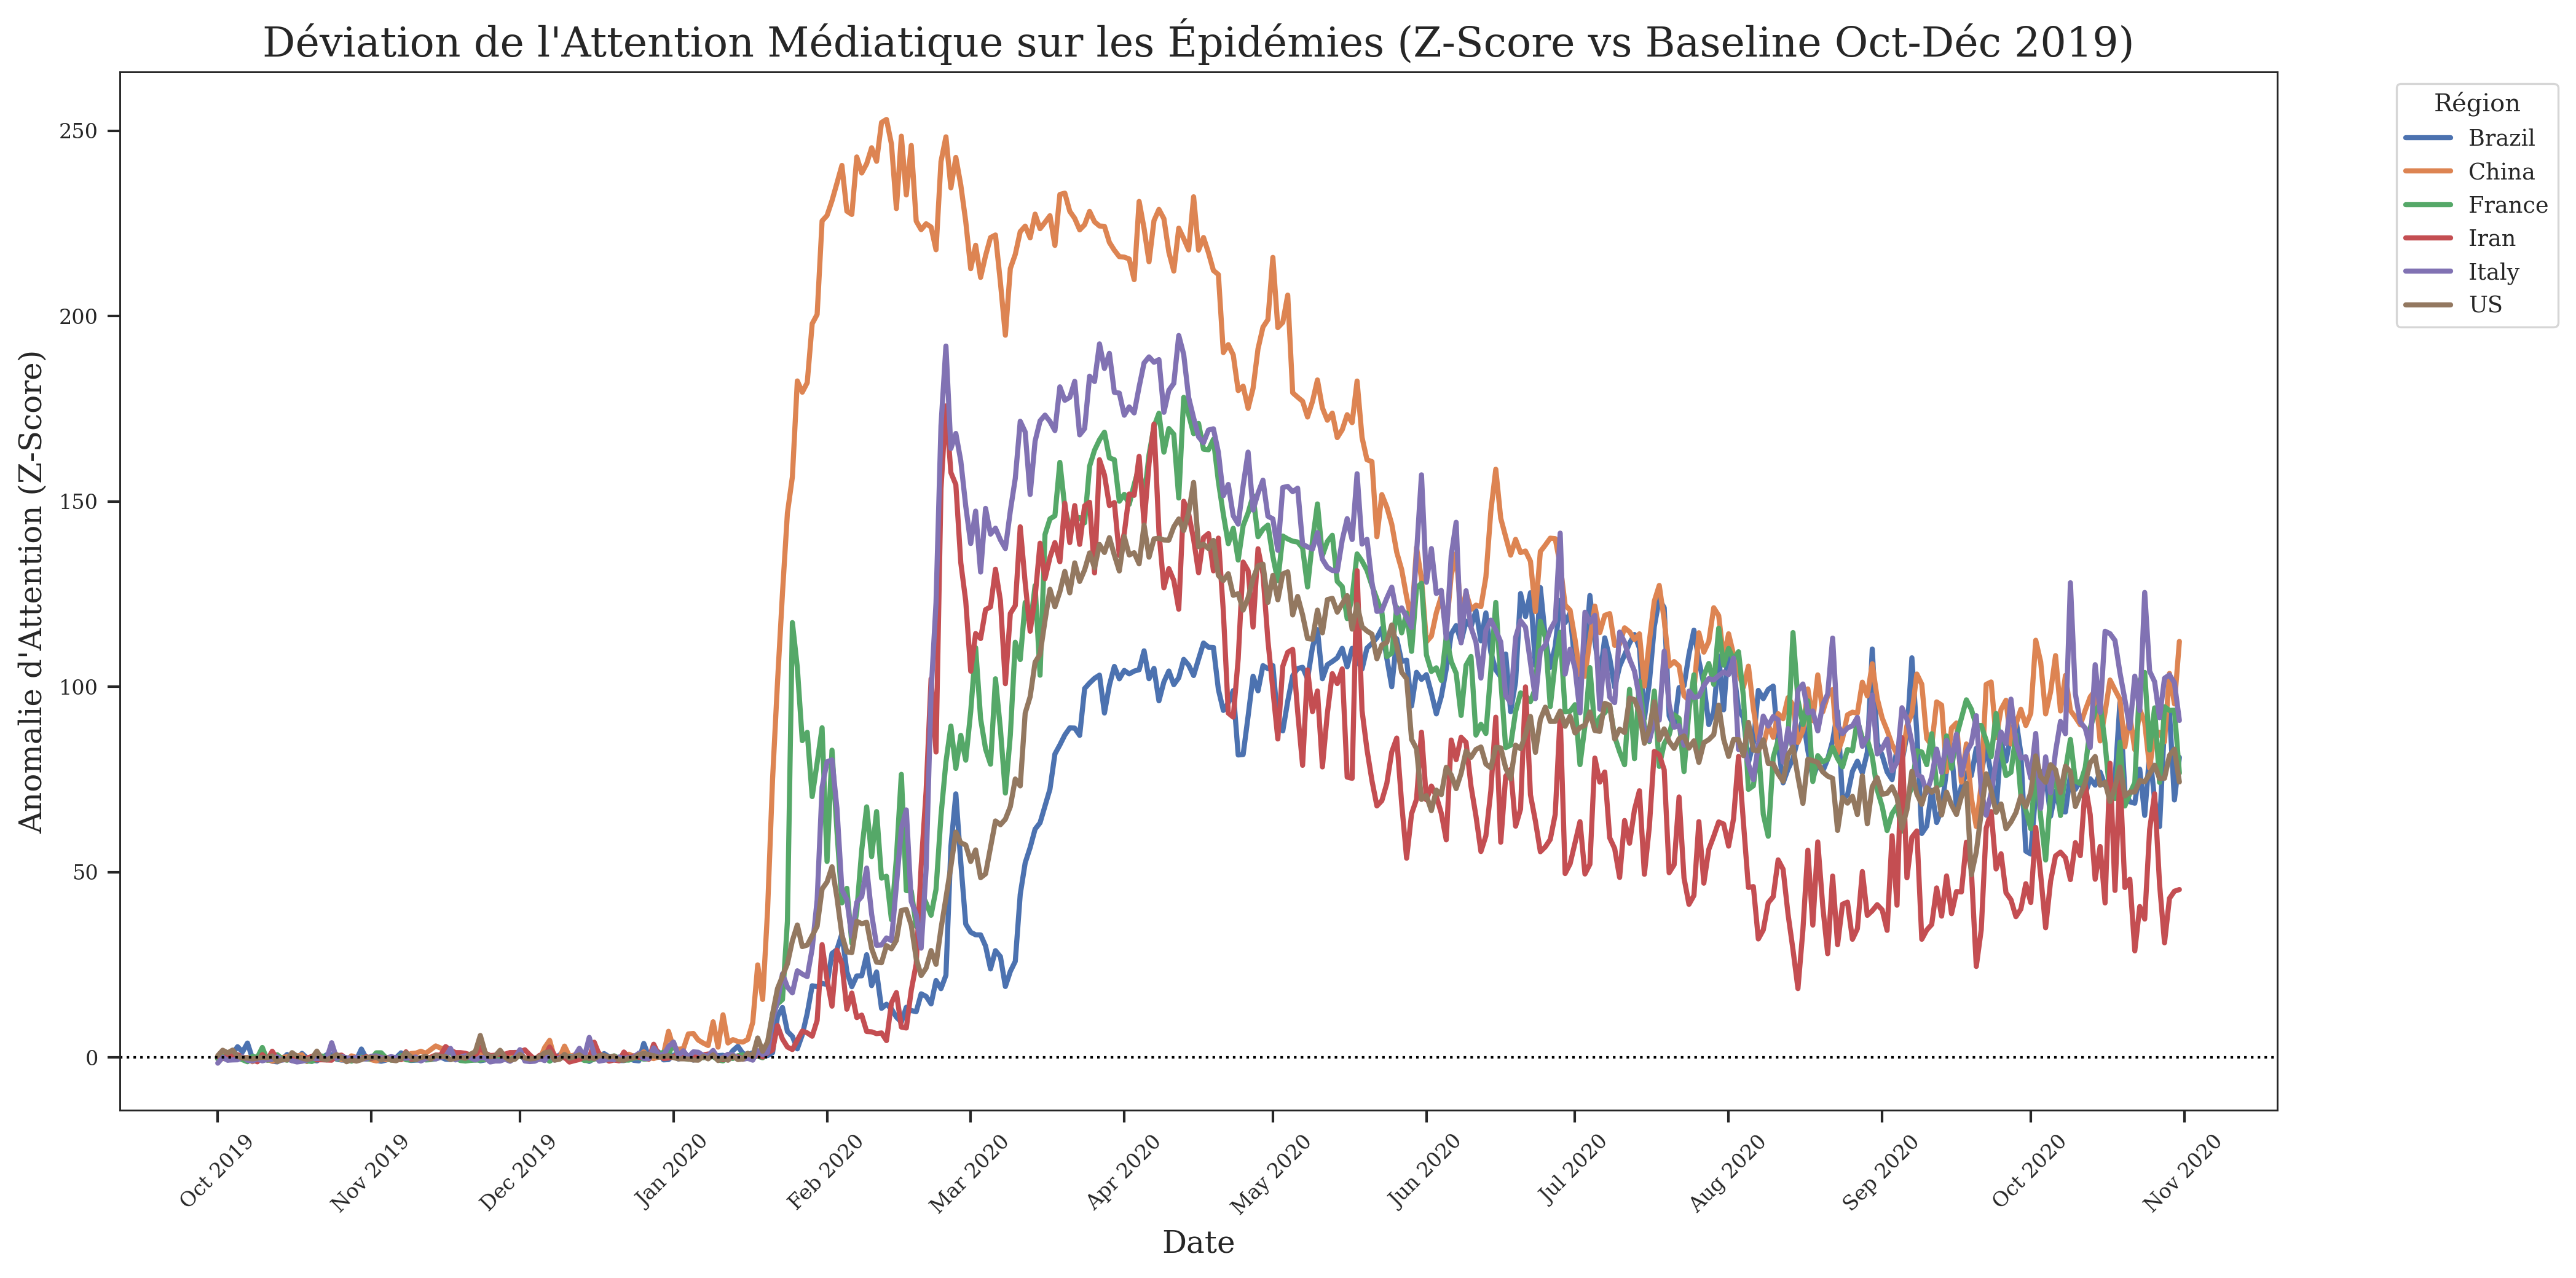

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
from pathlib import Path

# ── 1. Paramètres de l'étude (Cas COVID-19) ───────────────────────────
# Fenêtre d'étude : Octobre 2019 à Octobre 2020 
START_WINDOW    = pd.to_datetime("2019-10-01 00:00:00")
END_WINDOW      = pd.to_datetime("2020-10-31 23:59:59")

# Baseline "Calme" : Octobre à Décembre 2019 (Avant l'explosion médiatique)
BASELINE_START  = pd.to_datetime("2019-01-01 00:00:00")
BASELINE_END    = pd.to_datetime("2019-12-31 23:59:59")

# Dossier où se trouvent tes fichiers
dir_geo = Path("data/indicators_geo_daily_COVID")

# ── 2. Chargement et Préparation des Données ──────────────────────────────
files = list(dir_geo.glob("health_2019_daily.parquet")) + list(dir_geo.glob("health_2020_daily.parquet"))

if files:
    df = pd.concat([pd.read_parquet(f) for f in files], ignore_index=True)
    df["period"] = pd.to_datetime(df["period"])
    df = df.groupby(["period", "region_key"], as_index=False).first()
    
    # Slicing sur la fenêtre d'événement
    df_event = df[(df["period"] >= START_WINDOW) & (df["period"] <= END_WINDOW)].copy()
    df_event.sort_values(by=["period", "region_key"], inplace=True)
else:
    raise FileNotFoundError(f"Aucun fichier parquet 'health' trouvé dans {dir_geo}")

# ── 3. Calcul des Métriques Anormales (Z-Scores) ──────────────────────────
def compute_event_abnormal_metrics(df_full, df_window, base_start, base_end, metric_cols):
    df_out = df_window.copy()
    # Calcul de la baseline par région
    baseline_df = df_full[(df_full["period"] >= base_start) & (df_full["period"] <= base_end)]
    
    for col in metric_cols:
        if col not in df_out.columns:
            continue
            
        stats = baseline_df.groupby("region_key")[col].agg(["mean", "std"]).reset_index()
        stats.rename(columns={"mean": f"{col}_base_mean", "std": f"{col}_base_std"}, inplace=True)
        
        df_out = df_out.merge(stats, on="region_key", how="left")
        
        # Calcul du Z-Score (Deviation par rapport à la baseline)
        df_out[f"{col}_zscore"] = (df_out[col] - df_out[f"{col}_base_mean"]) / df_out[f"{col}_base_std"].replace(0, np.nan)
        df_out.drop(columns=[f"{col}_base_mean", f"{col}_base_std"], inplace=True)
        
    return df_out

target_metrics = [c for c in df_event.columns if c.startswith(("att_weight_", "sent_cont_weight_"))]
df_event_proc = compute_event_abnormal_metrics(df, df_event, BASELINE_START, BASELINE_END, target_metrics)

# ── 4. Visualisation Graphique ─────────────────────────────────────────────

# Filtrer sur la sous-catégorie spécifique "épidémies"
metric_to_plot = 'att_weight_health_epidemics_and_emergencies_zscore' 

if metric_to_plot in df_event_proc.columns:
    plt.figure(figsize=(14, 7))
    
    sns.lineplot(
        data=df_event_proc,
        x="period",
        y=metric_to_plot,
        hue="region_key",
        linewidth=2
    )
    
    # Ligne horizontale à 0 (baseline moyenne)
    plt.axhline(y=0, color='black', linestyle=':', linewidth=1)
    
    plt.title("Déviation de l'Attention Médiatique sur les Épidémies (Z-Score vs Baseline Oct-Déc 2019)", fontsize=16)
    plt.xlabel("Date", fontsize=12)
    plt.ylabel("Anomalie d'Attention (Z-Score)", fontsize=12)
    
    # Formatage des dates sur l'axe X
    ax = plt.gca()
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    plt.xticks(rotation=45)
    
    plt.legend(title="Région", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()
else:
    print(f"La métrique {metric_to_plot} n'a pas été trouvée dans les données.")

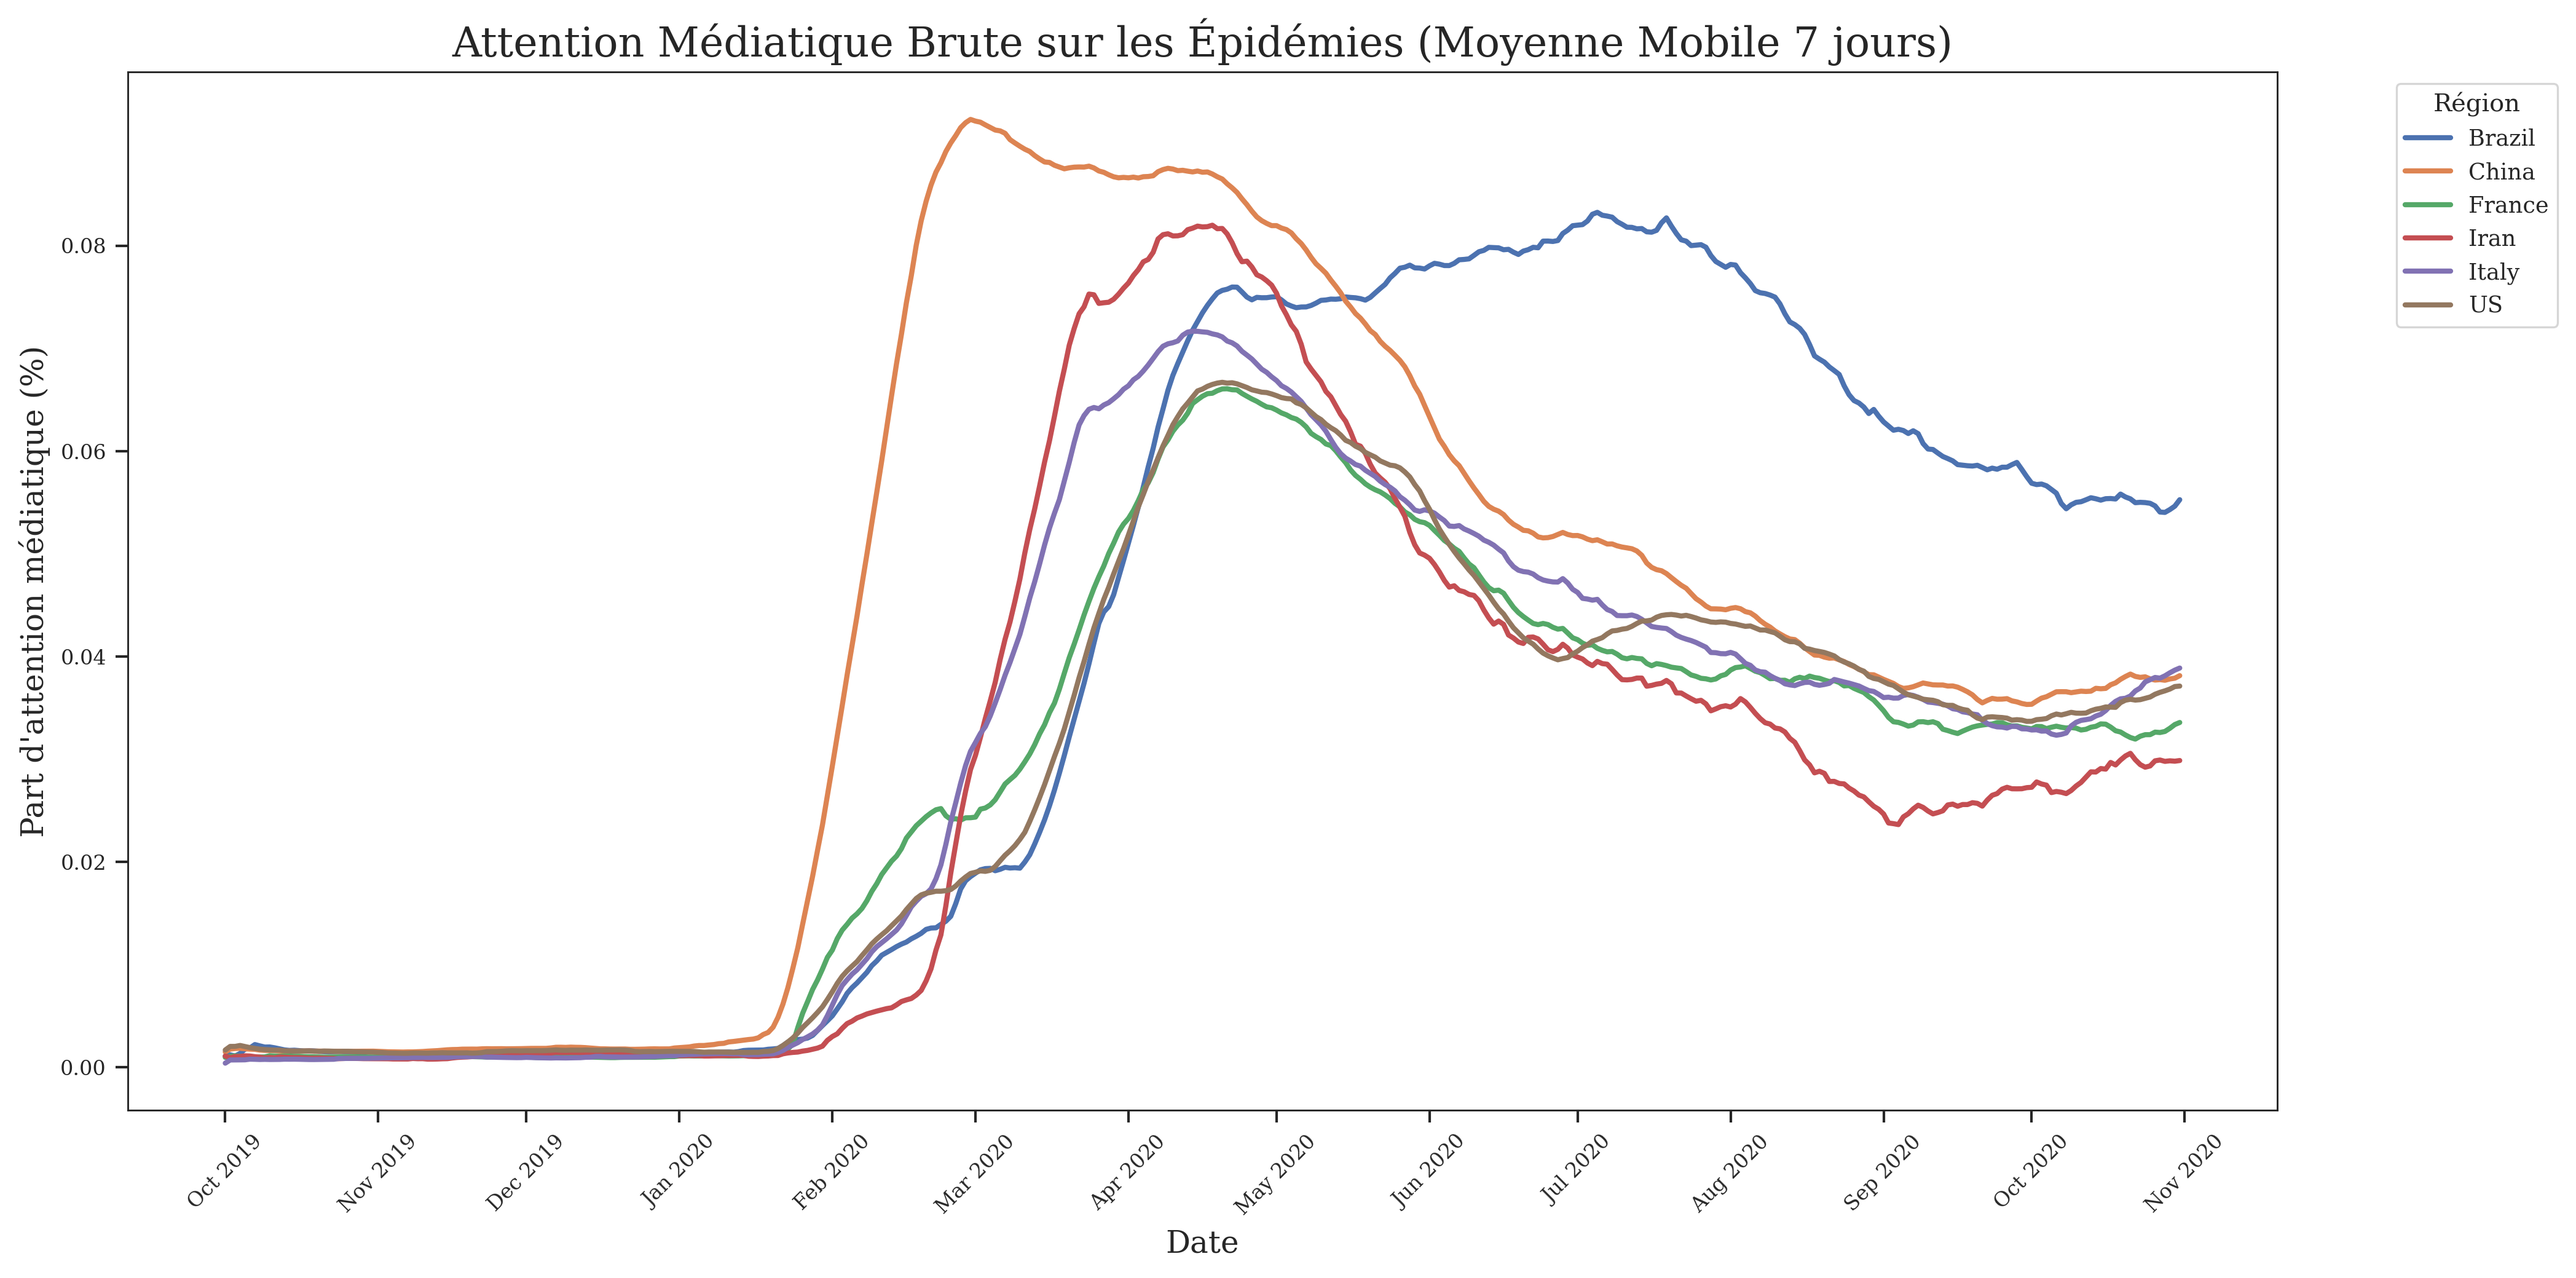

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
from pathlib import Path

# ── 1. Paramètres de l'étude (Cas COVID-19) ───────────────────────────
START_WINDOW    = pd.to_datetime("2019-10-01 00:00:00")
END_WINDOW      = pd.to_datetime("2020-10-31 23:59:59")
dir_geo         = Path("data/indicators_geo_daily_COVID")

# ── 2. Chargement des Données Brutes ──────────────────────────────────────
files = list(dir_geo.glob("health_2019_daily.parquet")) + list(dir_geo.glob("health_2020_daily.parquet"))

if files:
    df = pd.concat([pd.read_parquet(f) for f in files], ignore_index=True)
    df["period"] = pd.to_datetime(df["period"])
    df = df.groupby(["period", "region_key"], as_index=False).first()
    
    # Slicing sur la fenêtre
    df_event = df[(df["period"] >= START_WINDOW) & (df["period"] <= END_WINDOW)].copy()
    df_event.sort_values(by=["period", "region_key"], inplace=True)
else:
    raise FileNotFoundError(f"Aucun fichier parquet 'health' trouvé dans {dir_geo}")

# ── 3. Lissage (Moyenne Mobile 7 Jours) ───────────────────────────────────
# La métrique brute de l'attention (sans z-score)
metric_raw = 'att_weight_health_epidemics_and_emergencies'

# Application d'une moyenne mobile pour gommer l'effet "week-end" des médias
df_event['att_smoothed'] = df_event.groupby('region_key')[metric_raw].transform(
    lambda x: x.rolling(window=30, min_periods=1).mean()
)

# ── 4. Visualisation Graphique ─────────────────────────────────────────────
plt.figure(figsize=(14, 7))

sns.lineplot(
    data=df_event,
    x="period",
    y="att_smoothed",
    hue="region_key",
    linewidth=2
)

plt.title("Attention Médiatique Brute sur les Épidémies (Moyenne Mobile 7 jours)", fontsize=16)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Part d'attention médiatique (%)", fontsize=12)

# Formatage des dates sur l'axe X
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45)

plt.legend(title="Région", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()